In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_csv("Global_Health_Statistics.csv")

In [5]:
df.head()

,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Age Group,Gender,Population Affected,...,Hospital Beds per 1000,Treatment Type,Average Treatment Cost (USD),Availability of Vaccines/Treatment,Recovery Rate (%),DALYs,Improvement in 5 Years (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)
0,Italy,2013,Malaria,Respiratory,0.95,1.55,8.42,0-18,Male,471007,...,7.58,Medication,21064,No,91.82,4493,2.16,16886,0.79,86.02
1,France,2002,Ebola,Parasitic,12.46,8.63,8.75,61+,Male,634318,...,5.11,Surgery,47851,Yes,76.65,2366,4.82,80639,0.74,45.52
2,Turkey,2015,COVID-19,Genetic,0.91,2.35,6.22,36-60,Male,154878,...,3.49,Vaccination,27834,Yes,98.55,41,5.81,12245,0.41,40.20
3,Indonesia,2011,Parkinson's Disease,Autoimmune,4.68,6.29,3.99,0-18,Other,446224,...,8.44,Surgery,144,Yes,67.35,3201,2.22,49336,0.49,58.47
4,Italy,2013,Tuberculosis,Genetic,0.83,13.59,7.01,61+,Male,472908,...,5.90,Medication,8908,Yes,50.06,2832,6.93,47701,0.50,48.14


In [6]:
df.dtypes

Country                                object
Year                                    int64
Disease Name                           object
Disease Category                       object
Prevalence Rate (%)                   float64
Incidence Rate (%)                    float64
Mortality Rate (%)                    float64
Age Group                              object
Gender                                 object
Population Affected                     int64
Healthcare Access (%)                 float64
Doctors per 1000                      float64
Hospital Beds per 1000                float64
Treatment Type                         object
Average Treatment Cost (USD)            int64
Availability of Vaccines/Treatment     object
Recovery Rate (%)                     float64
DALYs                                   int64
Improvement in 5 Years (%)            float64
Per Capita Income (USD)                 int64
Education Index                       float64
Urbanization Rate (%)             

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,1000000.0,2011.996999,7.217287,2000.0,2006.00,2012.00,2018.00,2024.0
Prevalence Rate (%),1000000.0,10.047992,5.740189,0.1,5.09,10.04,15.01,20.0
Incidence Rate (%),1000000.0,7.555005,4.298947,0.1,3.84,7.55,11.28,15.0
Mortality Rate (%),1000000.0,5.049919,2.859427,0.1,2.58,5.05,7.53,10.0
Population Affected,1000000.0,500735.427363,288660.116648,1000.0,250491.25,501041.00,750782.00,1000000.0
Healthcare Access (%),1000000.0,74.987835,14.436345,50.0,62.47,75.00,87.49,100.0
Doctors per 1000,1000000.0,2.747929,1.299067,0.5,1.62,2.75,3.87,5.0
Hospital Beds per 1000,1000000.0,5.245931,2.742865,0.5,2.87,5.24,7.62,10.0
Average Treatment Cost (USD),1000000.0,25010.313665,14402.279227,100.0,12538.00,24980.00,37493.00,50000.0
Recovery Rate (%),1000000.0,74.496934,14.155168,50.0,62.22,74.47,86.78,99.0


In [23]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

label_encoder = LabelEncoder()
oh_encoder = OneHotEncoder()

In [28]:
encoded_data = oh_encoder.fit_transform(df[['Gender']]).toarray()
encoded_data

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [31]:
df["Disease Category"] = label_encoder.fit_transform(df['Disease Category'])
df["Disease Name"] = label_encoder.fit_transform(df['Disease Name'])
df["Treatment Type"] = label_encoder.fit_transform(df['Treatment Type'])
df["Country"] = label_encoder.fit_transform(df['Country'])





In [32]:
df.head()

,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Age Group,Gender,Population Affected,...,Hospital Beds per 1000,Treatment Type,Average Treatment Cost (USD),Availability of Vaccines/Treatment,Recovery Rate (%),DALYs,Improvement in 5 Years (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)
0,9,2013,13,9,0.95,1.55,8.42,0-18,Male,471007,...,7.58,0,21064,No,91.82,4493,2.16,16886,0.79,86.02
1,5,2002,7,8,12.46,8.63,8.75,61+,Male,634318,...,5.11,1,47851,Yes,76.65,2366,4.82,80639,0.74,45.52
2,17,2015,2,4,0.91,2.35,6.22,36-60,Male,154878,...,3.49,3,27834,Yes,98.55,41,5.81,12245,0.41,40.20
3,8,2011,15,0,4.68,6.29,3.99,0-18,Other,446224,...,8.44,1,144,Yes,67.35,3201,2.22,49336,0.49,58.47
4,9,2013,18,4,0.83,13.59,7.01,61+,Male,472908,...,5.90,0,8908,Yes,50.06,2832,6.93,47701,0.50,48.14


In [8]:
df.isnull().sum()

Country                               0
Year                                  0
Disease Name                          0
Disease Category                      0
Prevalence Rate (%)                   0
Incidence Rate (%)                    0
Mortality Rate (%)                    0
Age Group                             0
Gender                                0
Population Affected                   0
Healthcare Access (%)                 0
Doctors per 1000                      0
Hospital Beds per 1000                0
Treatment Type                        0
Average Treatment Cost (USD)          0
Availability of Vaccines/Treatment    0
Recovery Rate (%)                     0
DALYs                                 0
Improvement in 5 Years (%)            0
Per Capita Income (USD)               0
Education Index                       0
Urbanization Rate (%)                 0
dtype: int64

In [9]:
df[df.isnull().any(axis=1)]

,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Age Group,Gender,Population Affected,...,Hospital Beds per 1000,Treatment Type,Average Treatment Cost (USD),Availability of Vaccines/Treatment,Recovery Rate (%),DALYs,Improvement in 5 Years (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)


In [10]:
df.dropna(inplace=True)

In [11]:
df.duplicated().any()

False

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 22 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   Country                             1000000 non-null  object 
 1   Year                                1000000 non-null  int64  
 2   Disease Name                        1000000 non-null  object 
 3   Disease Category                    1000000 non-null  object 
 4   Prevalence Rate (%)                 1000000 non-null  float64
 5   Incidence Rate (%)                  1000000 non-null  float64
 6   Mortality Rate (%)                  1000000 non-null  float64
 7   Age Group                           1000000 non-null  object 
 8   Gender                              1000000 non-null  object 
 9   Population Affected                 1000000 non-null  int64  
 10  Healthcare Access (%)               1000000 non-null  float64
 11  Doctors per 

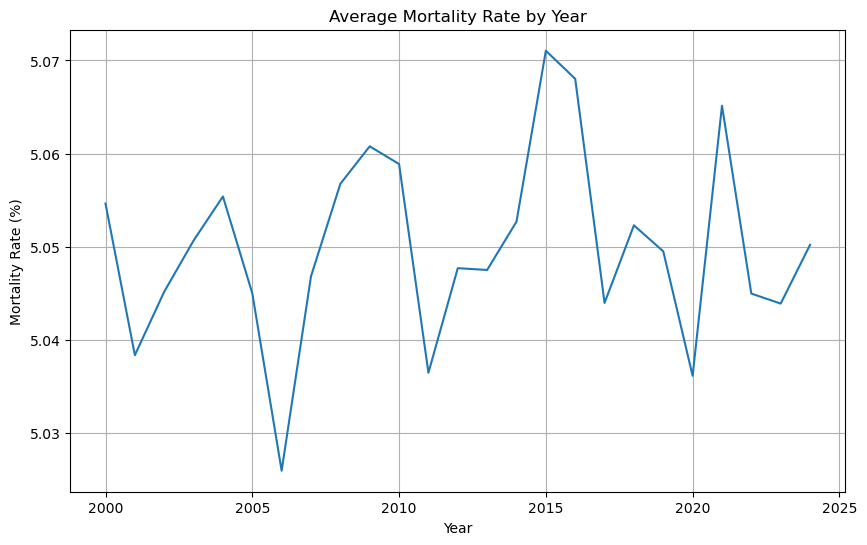

In [13]:
yil_mortalite = df.groupby("Year")["Mortality Rate (%)"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=yil_mortalite, x="Year", y="Mortality Rate (%)")
plt.title("Average Mortality Rate by Year")
plt.ylabel("Mortality Rate (%)")
plt.grid(True)
plt.show()

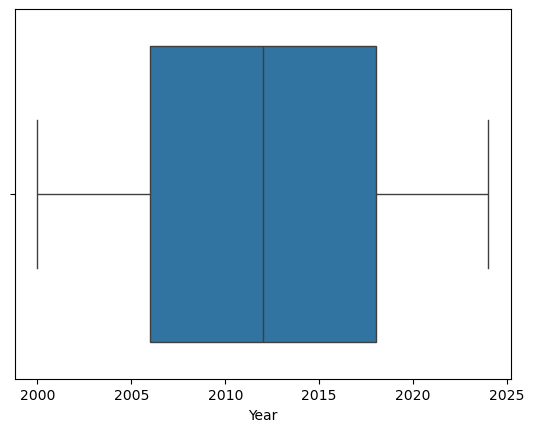

In [14]:
sns.boxplot(x=df["Year"])
plt.show()

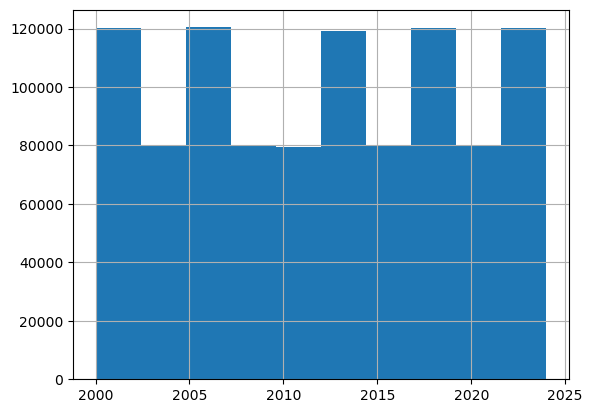

In [15]:
df["Year"].hist()
plt.show()

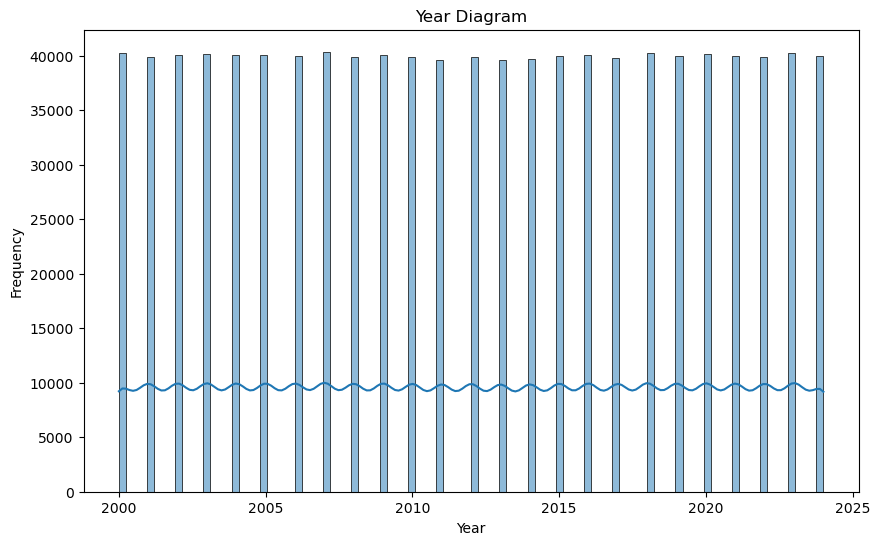

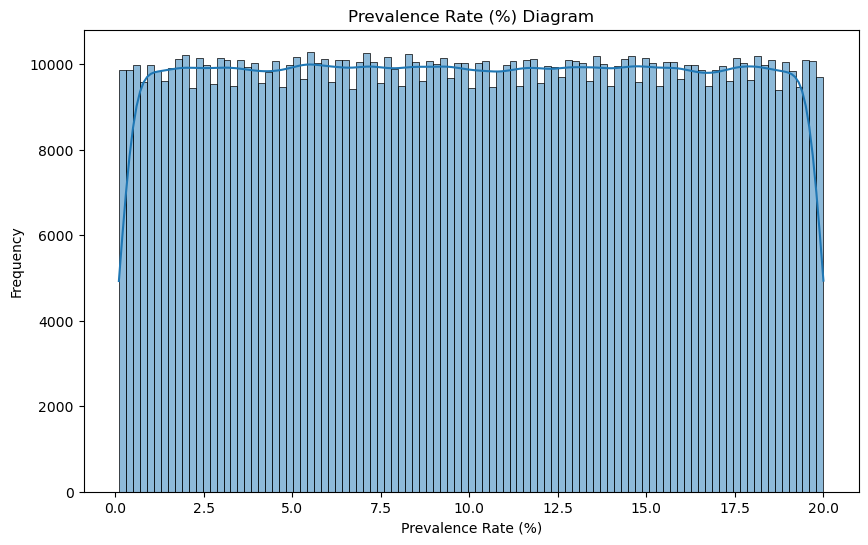

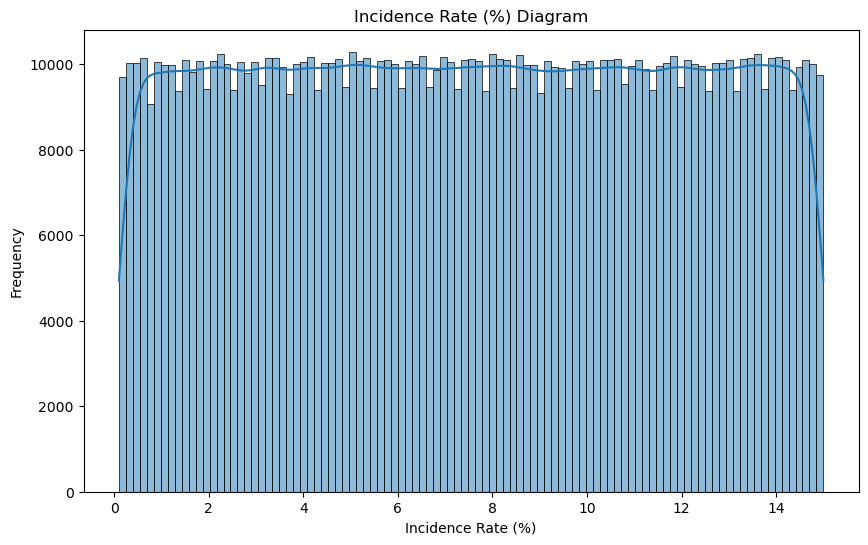

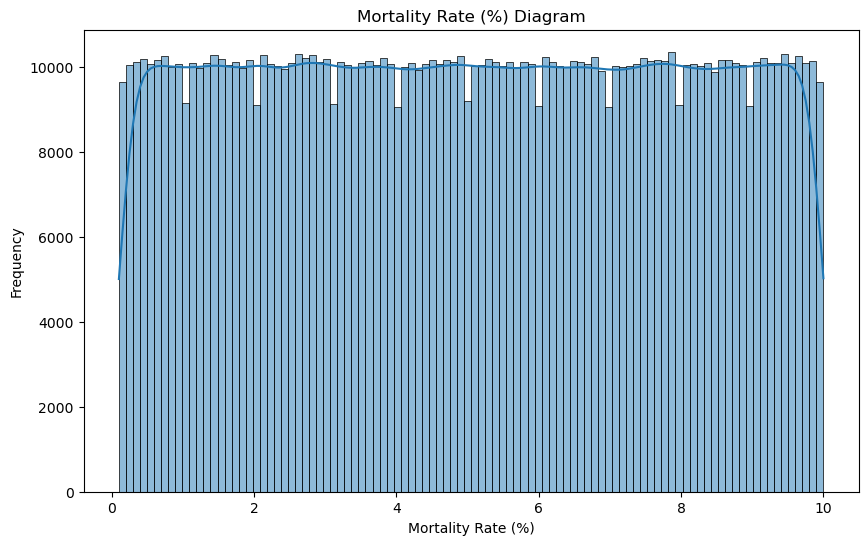

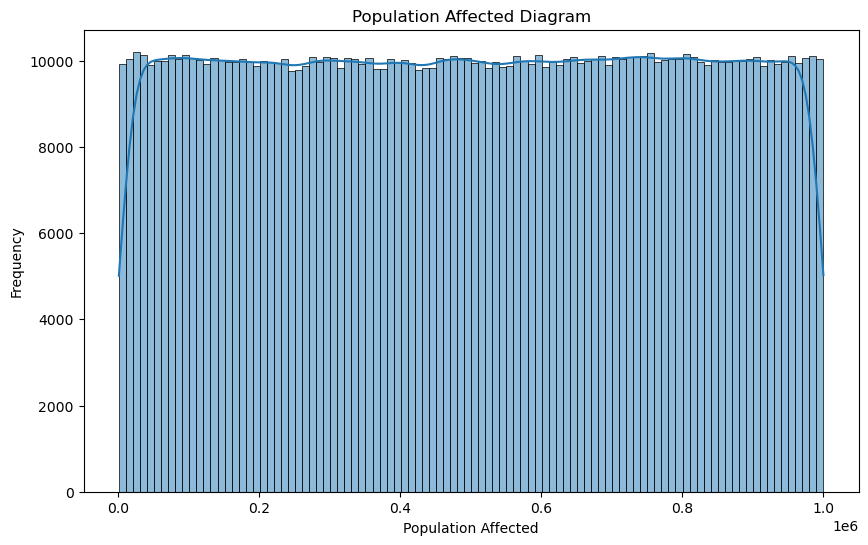

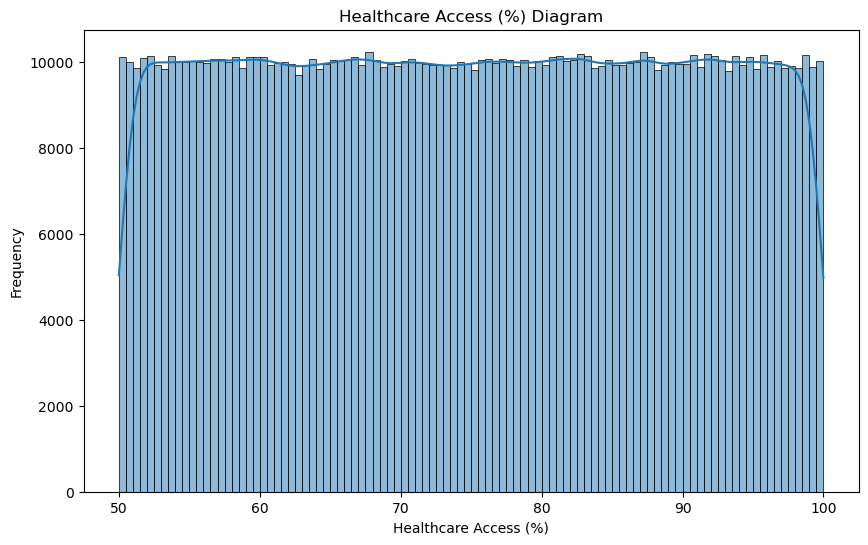

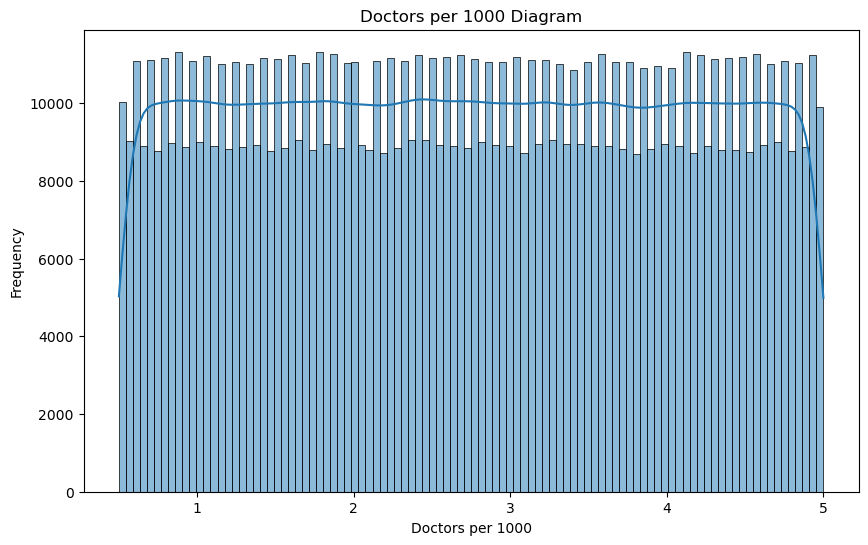

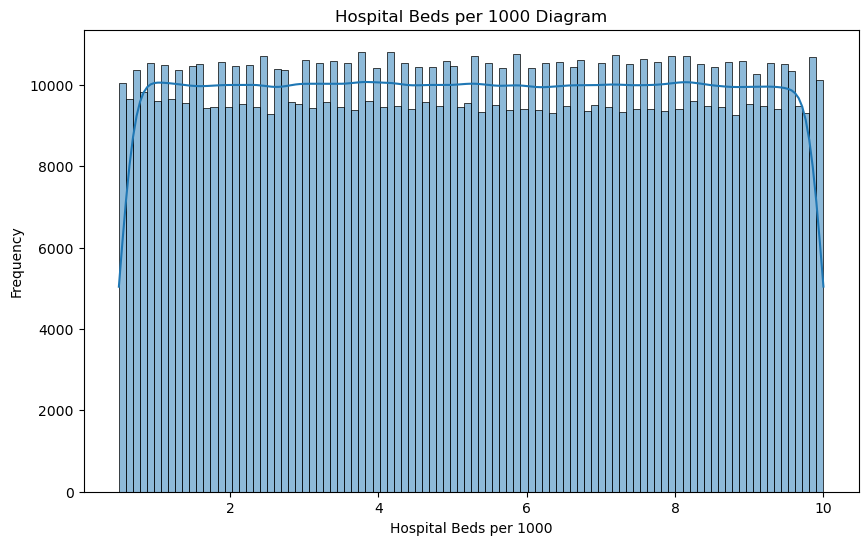

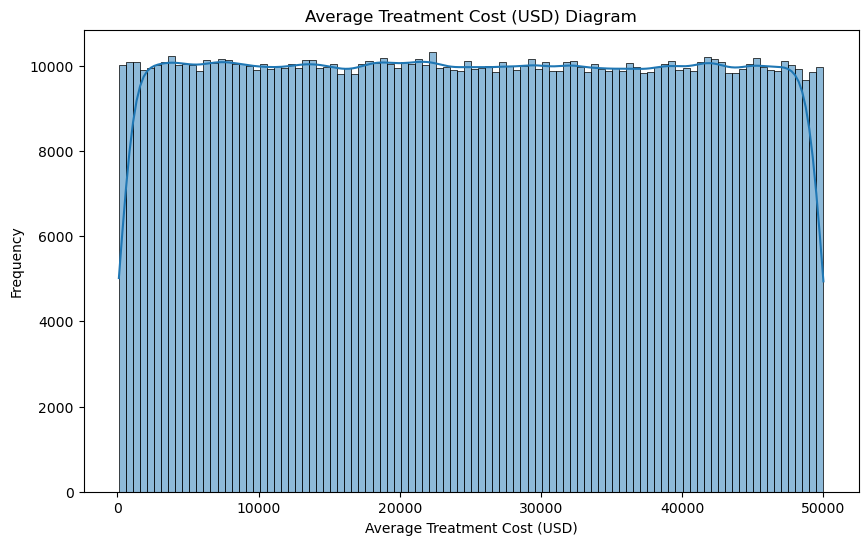

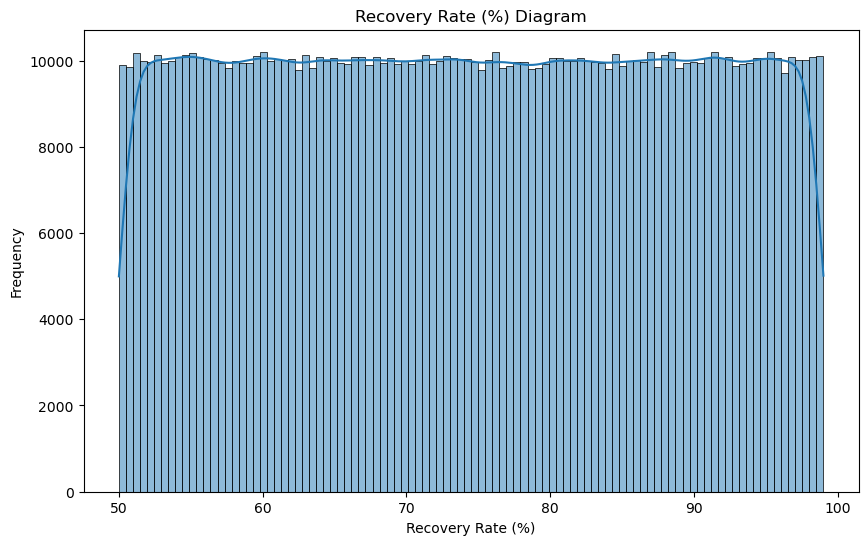

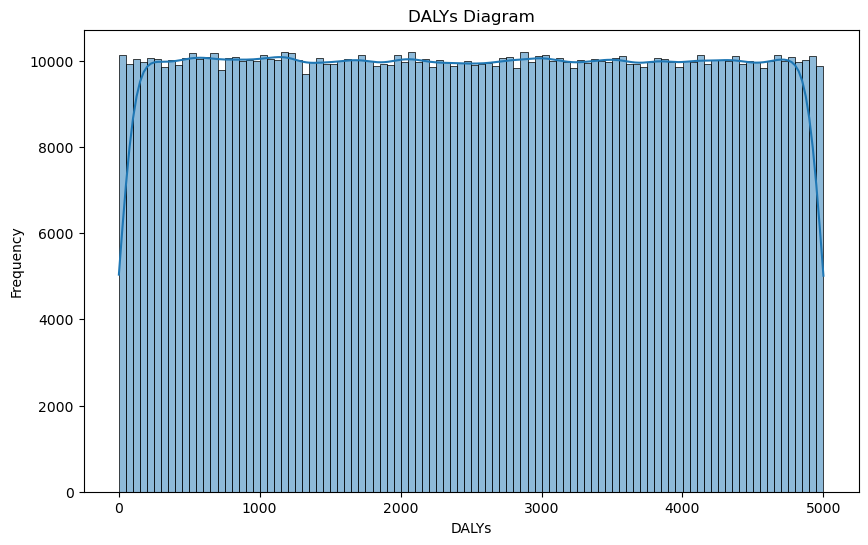

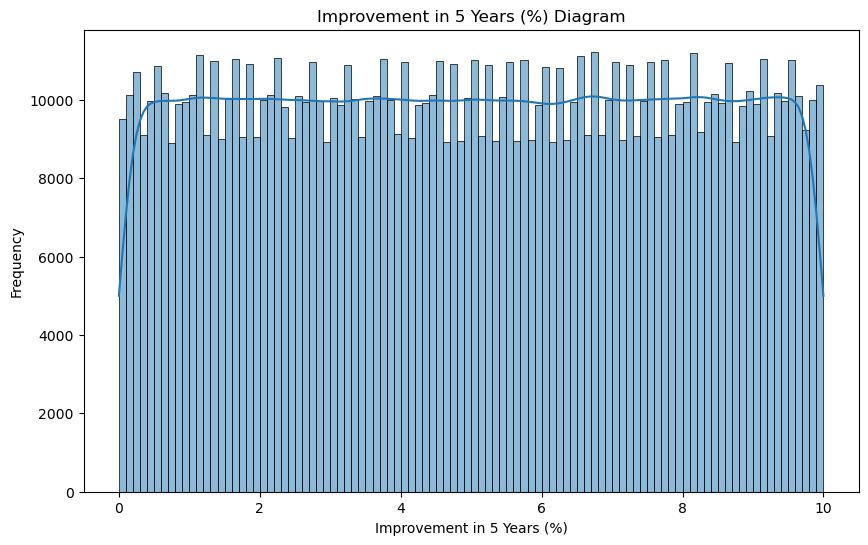

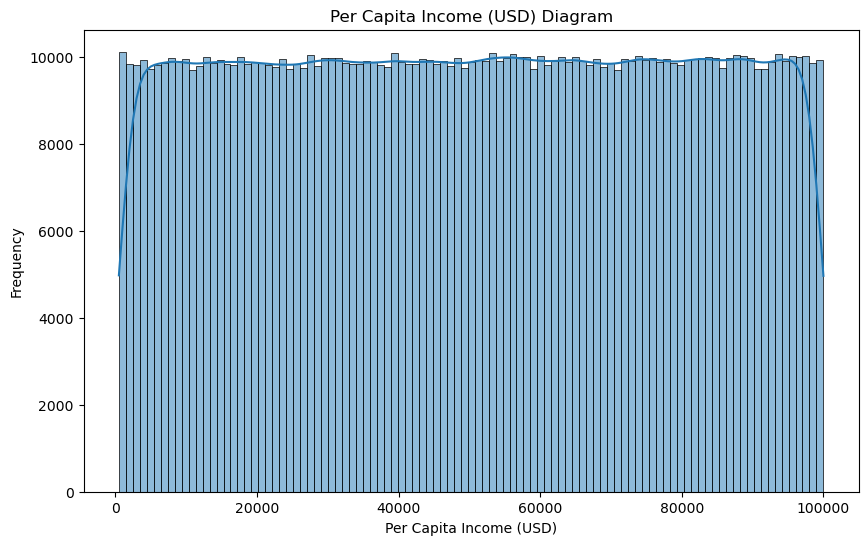

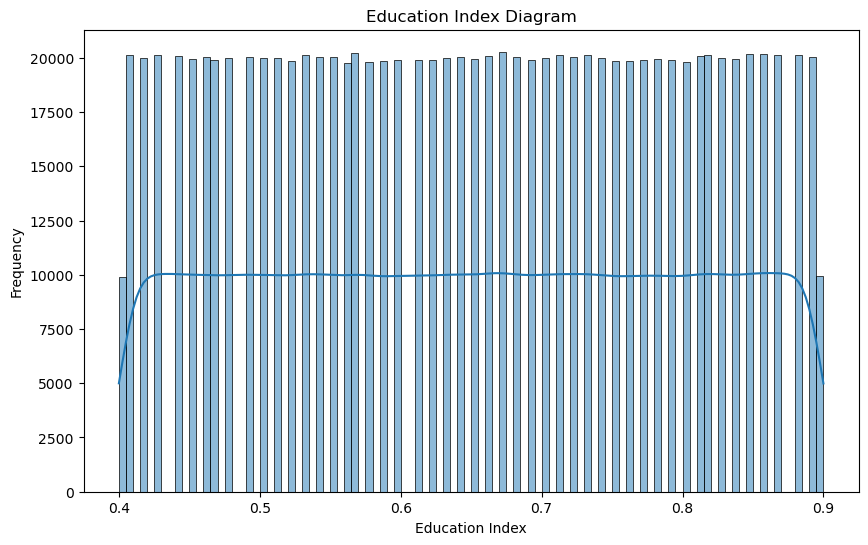

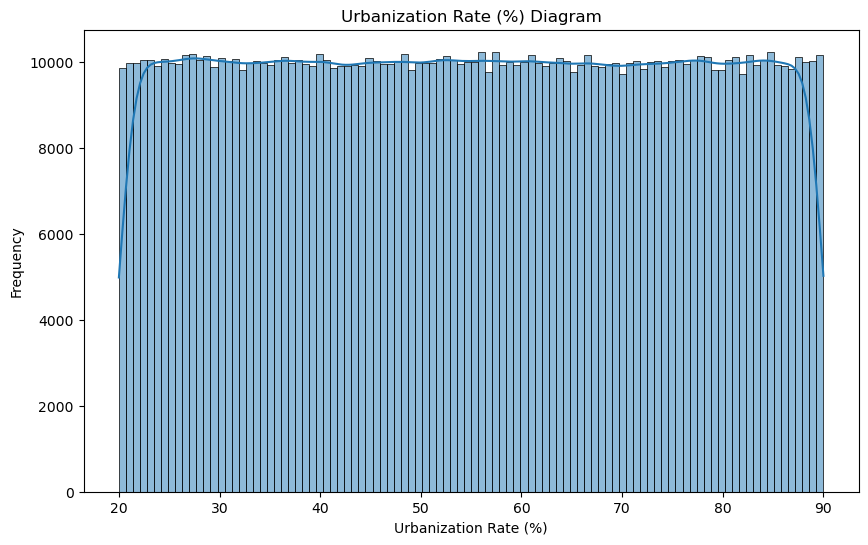

In [16]:
num_cols = df.select_dtypes(include=[np.number]).columns

for col in num_cols:
    plt.figure(figsize=(10,6))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Diagram")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [17]:
sns.pairplot(df, size = 8)
plt.show()

c:\Users\chint\anaconda3\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


KeyboardInterrupt: 

In [18]:
corr_vars = ["Mortality Rate (%)", "Recovery Rate (%)", "Doctors per 1000",
             "Hospital Beds per 1000", "Healthcare Access (%)",
             "Per Capita Income (USD)", "Education Index", "Urbanization Rate (%)"]

corr_matrix = df[corr_vars].corr()

In [19]:
corr_matrix

,Mortality Rate (%),Recovery Rate (%),Doctors per 1000,Hospital Beds per 1000,Healthcare Access (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)
Mortality Rate (%),1.000000,0.000736,0.000820,0.000769,0.000077,-0.001503,-0.000110,0.000169
Recovery Rate (%),0.000736,1.000000,-0.001308,-0.001030,0.001598,0.000287,-0.001678,0.001231
Doctors per 1000,0.000820,-0.001308,1.000000,0.001585,0.000617,0.000672,0.000687,-0.000322
Hospital Beds per 1000,0.000769,-0.001030,0.001585,1.000000,-0.000269,0.000564,-0.002227,-0.001470
Healthcare Access (%),0.000077,0.001598,0.000617,-0.000269,1.000000,-0.001308,0.001085,0.000363
Per Capita Income (USD),-0.001503,0.000287,0.000672,0.000564,-0.001308,1.000000,-0.000564,0.000104
Education Index,-0.000110,-0.001678,0.000687,-0.002227,0.001085,-0.000564,1.000000,-0.000174
Urbanization Rate (%),0.000169,0.001231,-0.000322,-0.001470,0.000363,0.000104,-0.000174,1.000000


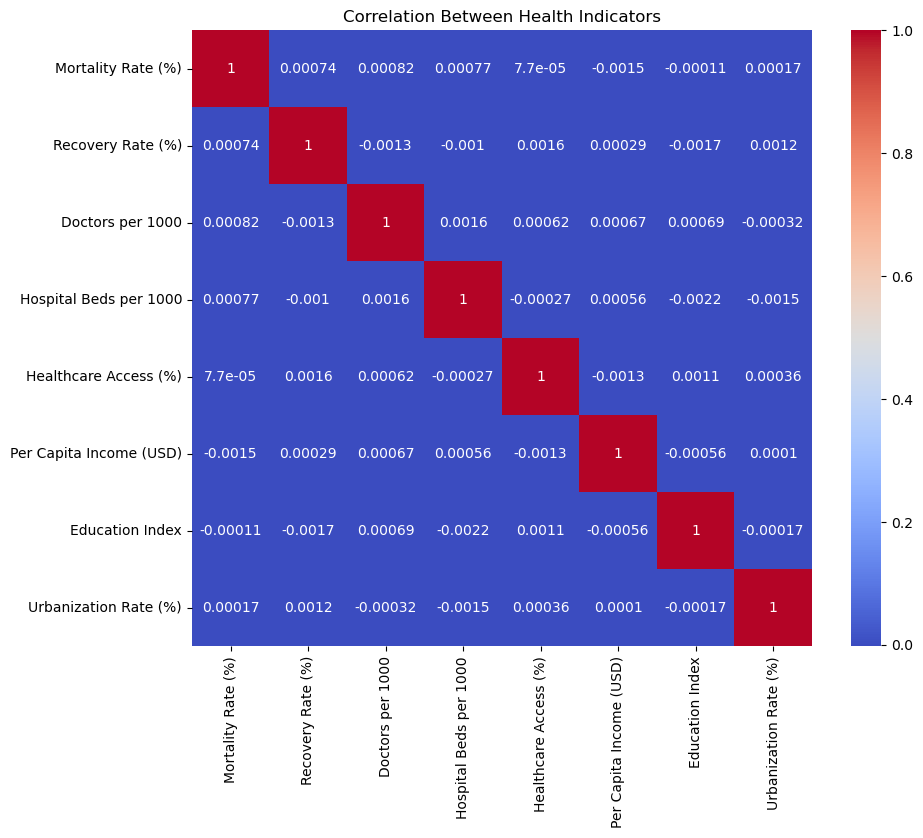

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Between Health Indicators")
plt.show()

In [21]:
X = df[["Doctors per 1000", "Hospital Beds per 1000", "Healthcare Access (%)",
        "Per Capita Income (USD)", "Education Index", "Urbanization Rate (%)"]]
y = df["Mortality Rate (%)"]

In [22]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
x_train.isnull().sum()

,0
Doctors per 1000,0
Hospital Beds per 1000,0
Healthcare Access (%),0
Per Capita Income (USD),0
Education Index,0
Urbanization Rate (%),0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
scalar = StandardScaler()

In [ ]:
x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.transform(x_test)

In [ ]:
x_train.isnull().sum()

,0
Doctors per 1000,0
Hospital Beds per 1000,0
Healthcare Access (%),0
Per Capita Income (USD),0
Education Index,0
Urbanization Rate (%),0


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "LightGBM": LGBMRegressor()
}

for name, model in models.items():
    print("======================================================================")
    print(f"Model: {name}")
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"MSE: {mse}")
    print(f"R^2: {r2}")

Model: Linear Regression
MSE: 8.193755861718415
R^2: -1.2527973711318197e-05
Model: Random Forest
MSE: 8.396438143024298
R^2: -0.024749025365722543
Model: Gradient Boosting
MSE: 8.194628549729646
R^2: -0.00011903577782135244
Model: XGBoost
MSE: 8.229519949838572
R^2: -0.004377380524274388
Model: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1326
[LightGBM] [Info] Number of data points in the train set: 800000, number of used features: 6
[LightGBM] [Info] Start training from score 5.050837


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MSE: 8.197097136355008
R^2: -0.00042031611780357636


In [ ]:
import pickle


with open("scalar.pkl", "wb") as f:
    pickle.dump(scalar, f)

with open("model.pkl", "wb") as f:
    pickle.dump(models["Random Forest"], f)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

for name, model in models.items():
    print("======================================================================")
    print(f"Model: {name}")
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)


    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)
    medae = median_absolute_error(y_test, y_pred)


    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"MAPE: {mape}%")
    print(f"Median AE: {medae}")
    print(f"R^2: {r2}")


Model: Linear Regression
MSE: 8.193755861718415
RMSE: 2.862473731183994
MAE: 2.479736396660663
MAPE: 165.49327459418336%
Median AE: 2.4782798108122
R^2: -1.2527973711318197e-05
Model: Random Forest
MSE: 8.387452279251148
RMSE: 2.8961098527595857
MAE: 2.4991884385
MAPE: 165.79685816809638%
Median AE: 2.4837499999999997
R^2: -0.023652339486930796
Model: Gradient Boosting
MSE: 8.19461742350201
RMSE: 2.862624219750474
MAE: 2.4798368079623496
MAPE: 165.49147398871833%
Median AE: 2.477888467718306
R^2: -0.00011767786977334715
Model: XGBoost
MSE: 8.229519949838572
RMSE: 2.868713988852596
MAE: 2.4833493728337293
MAPE: 165.5779929447768%
Median AE: 2.477006206512451
R^2: -0.004377380524274388
Model: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045522 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1326
[LightGBM] [Info] Number of data points in the train set: 800000, number of used features: 6
[L

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MSE: 8.197097136355008
RMSE: 2.8630573058105226
MAE: 2.4801122404274905
MAPE: 165.509938321277%
Median AE: 2.4782346738139642
R^2: -0.00042031611780357636
